# Task

- Reuse VAE implementation from the previous homework
- Combine it with your diffusion pipeline to train a Latent Diffusion Model (LDM) operating in the VAE’s latent space
- Compare inference results and generation speed between:
    - Pixel-space DDPM/DDIM
    - Latent-space DDPM/DDIM

# Disclaimer

This notebook is both an implementation and a report with visualizations and justifications of approaches and results. There is no separate final report due to the inconvenience of reproducing the same structure in pdf.

Additional detailed explanations regarding parts that have been reused from previous works can be found in the relevant notebooks; they are not repeated here.

# Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from tqdm.auto import tqdm
import math
import time
from dataclasses import dataclass
from typing import Optional, Tuple, List, Dict

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Data Preparation

In [2]:
def get_mnist_loaders(
    dataset: str = "mnist",
    data_root: str = "./data",
    batch_size: int = 128,
    val_split: float = 0.1,
):
    if dataset == "mnist":
        DatasetClass = datasets.MNIST
    else:
        DatasetClass = datasets.FashionMNIST

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),  # (x - 0.5) / 0.5 -> [-1, 1]
    ])

    full_train = DatasetClass(root=data_root, train=True, download=True, transform=transform)
    test_ds = DatasetClass(root=data_root, train=False, download=True, transform=transform)

    n_total = len(full_train)
    n_val = int(n_total * val_split)
    n_train = n_total - n_val

    print(f"\n--- {dataset.upper()} DATASET ---")
    print(f"Total train images: {n_total}")
    print(f"  Train split:      {n_train}")
    print(f"  Validation split: {n_val}")
    print(f"Test set size:      {len(test_ds)}\n")

    train_ds, val_ds = random_split(
        full_train, [n_train, n_val],
        generator=torch.Generator().manual_seed(42),
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader


def show_samples(loader, title: str):
    x, y = next(iter(loader))
    x, y = x[:4], y[:4]
    fig, axes = plt.subplots(1, 4, figsize=(8, 2))
    fig.suptitle(title)
    for i in range(4):
        axes[i].imshow(x[i].squeeze(0), cmap="gray")
        axes[i].set_title(f"label: {y[i].item()}")
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.72MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.5MB/s]



--- MNIST DATASET ---
Total train images: 60000
  Train split:      54000
  Validation split: 6000
Test set size:      10000



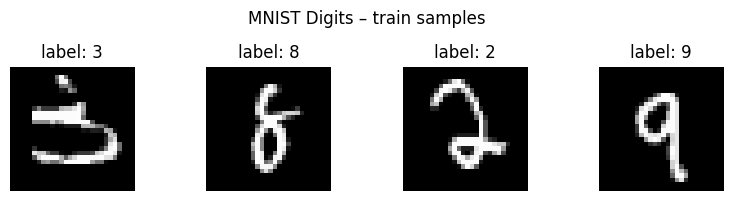

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 171kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.38MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.6MB/s]



--- FASHION DATASET ---
Total train images: 60000
  Train split:      54000
  Validation split: 6000
Test set size:      10000



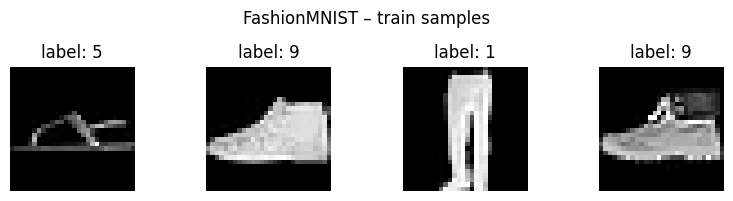

In [3]:
train_digits, val_digits, test_digits = get_mnist_loaders(dataset="mnist", batch_size=128)
show_samples(train_digits, "MNIST Digits – train samples")

train_fashion, val_fashion, test_fashion = get_mnist_loaders(dataset="fashion", batch_size=128)
show_samples(train_fashion, "FashionMNIST – train samples")

# General Helpers

In [4]:
def denormalize(x: torch.Tensor) -> torch.Tensor:
    """Convert images from [-1, 1] back to [0, 1]"""
    return (x.clamp(-1, 1) + 1) / 2


def show_generated_grid(
    samples: torch.Tensor,
    nrow: int = 8,
    title: str = "Generated Samples",
    figsize: Tuple = (10, 10),
):
    samples = denormalize(samples).cpu()
    n = samples.shape[0]
    ncol = min(nrow, n)
    nrows = math.ceil(n / ncol)

    fig, axes = plt.subplots(nrows, ncol, figsize=figsize)
    if nrows == 1:
        axes = axes[None, :]
    fig.suptitle(title, fontsize=14)

    for i in range(nrows):
        for j in range(ncol):
            idx = i * ncol + j
            if idx < n:
                axes[i, j].imshow(samples[idx].squeeze(0), cmap="gray")
            axes[i, j].axis("off")
    plt.tight_layout()
    plt.show()


def plot_losses(train_losses: list, val_losses: list, title: str = "Training & Validation Loss"):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(train_losses, label="Train Loss")
    ax.plot(val_losses, label="Val Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


@dataclass
class TrainConfig:
    epochs: int = 30
    lr: float = 2e-4
    grad_clip: float = 1.0
    ema_decay: float = 0.9999


class EMA:
    """Exponential Moving Average for model parameters"""
    def __init__(self, model: nn.Module, decay: float = 0.9999):
        self.decay = decay
        self.shadow = {
            name: p.clone().detach()
            for name, p in model.named_parameters() if p.requires_grad
        }
        self.backup = {}

    @torch.no_grad()
    def update(self, model: nn.Module):
        for name, p in model.named_parameters():
            if p.requires_grad and name in self.shadow:
                self.shadow[name].mul_(self.decay).add_(p.data, alpha=1 - self.decay)

    def apply(self, model: nn.Module):
        self.backup = {
            name: p.data.clone()
            for name, p in model.named_parameters() if p.requires_grad
        }
        for name, p in model.named_parameters():
            if name in self.shadow:
                p.data.copy_(self.shadow[name])

    def restore(self, model: nn.Module):
        for name, p in model.named_parameters():
            if name in self.backup:
                p.data.copy_(self.backup[name])

# VAE

Reused from previous homework VAE compresses 28×28 images into a 32-dimensional latent vector.
This latent space is where we will run diffusion.

**Important** difference from standard LDM (Stable Diffusion): real LDMs use
[spatial latents](https://arxiv.org/pdf/2112.10752#page=3) (for example 4×32×32). This VAE produces a flat 32-dim vector, so we will use an MLP-based noise predictor instead of a U-Net. The core LDM concept idea to train diffusion in compressed space is identical.

## VAE Architecture

In [5]:
class ConvVAEEncoder(nn.Module):
    """
    Convolutional VAE encoder
    (B, 1, 28, 28) -> (mu, logvar) of shape (B, latent_dim)
    """

    def __init__(self, latent_dim: int = 32):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1)   # 28->14
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)  # 14->7
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)  # 7->7

        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(64)

        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)
        self.latent_dim = latent_dim

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = x.view(x.size(0), -1)
        return self.fc_mu(x), self.fc_logvar(x)


class ConvVAEDecoder(nn.Module):
    """
    Convolutional VAE decoder
    (B, latent_dim) -> (B, 1, 28, 28)
    """

    def __init__(self, latent_dim: int = 32):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 64 * 7 * 7)

        self.deconv1 = nn.ConvTranspose2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.deconv2 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.deconv3 = nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1)

        self.bn1 = nn.BatchNorm2d(64)
        self.bn2 = nn.BatchNorm2d(32)
        self.latent_dim = latent_dim

    def forward(self, z):
        x = self.fc(z)
        x = x.view(x.size(0), 64, 7, 7)
        x = F.relu(self.bn1(self.deconv1(x)))
        x = F.relu(self.bn2(self.deconv2(x)))
        x = torch.sigmoid(self.deconv3(x))
        return x


class ConvVAE(nn.Module):
    """Convolutional Variational Autoencoder"""

    def __init__(self, latent_dim: int = 32):
        super().__init__()
        self.encoder = ConvVAEEncoder(latent_dim=latent_dim)
        self.decoder = ConvVAEDecoder(latent_dim=latent_dim)
        self.latent_dim = latent_dim

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(z)
        return x_recon, mu, logvar

    @torch.no_grad()
    def encode(self, x):
        """Encode to latent mean (deterministic for dataset pre-encoding)"""
        mu, _ = self.encoder(x)
        return mu

    @torch.no_grad()
    def decode(self, z):
        """Decode latent vector to image"""
        return self.decoder(z)

## Train the VAE

The VAE needs to be trained first so that its latent space has meaningful structure.
We train with the standard VAE loss: reconstruction (BCE) + KL divergence.

**Note on normalization:** the data loader produces images in $[-1, 1]$, but the VAE decoder uses sigmoid (output in $[0, 1]$), so the initial images are converted to $[0, 1]$ before computing BCE.

In [6]:
def vae_loss_fn(x_recon, x_target, mu, logvar, beta: float = 1.0):
    """VAE loss = MSE reconstruction (sum/batch) + β * KL divergence (sum/batch)"""
    recon_loss = F.mse_loss(x_recon, x_target, reduction='sum') / x_target.size(0)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x_target.size(0)
    return recon_loss + beta * kl_loss, recon_loss, kl_loss


def train_vae(
    model: ConvVAE,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = 20,
    lr: float = 1e-3,
    beta: float = 1.0,
    device: str = "cuda",
) -> Tuple[ConvVAE, dict]:
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_recon": [], "train_kl": []}

    for epoch in range(epochs):
        model.train()
        epoch_loss, epoch_recon, epoch_kl, n = 0, 0, 0, 0

        pbar = tqdm(train_loader, desc=f"VAE Epoch {epoch+1}/{epochs}")
        for x, _ in pbar:
            x_01 = (x.to(device) + 1) / 2  # [-1,1] -> [0,1]

            x_recon, mu, logvar = model(x_01)
            loss, recon, kl = vae_loss_fn(x_recon, x_01, mu, logvar, beta)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            epoch_recon += recon.item()
            epoch_kl += kl.item()
            n += 1
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        model.eval()
        val_loss_sum, val_n = 0, 0
        with torch.no_grad():
            for x, _ in val_loader:
                x_01 = (x.to(device) + 1) / 2
                x_recon, mu, logvar = model(x_01)
                loss, _, _ = vae_loss_fn(x_recon, x_01, mu, logvar, beta)
                val_loss_sum += loss.item()
                val_n += 1

        history["train_loss"].append(epoch_loss / n)
        history["val_loss"].append(val_loss_sum / val_n)
        history["train_recon"].append(epoch_recon / n)
        history["train_kl"].append(epoch_kl / n)

        print(f"  => loss: {epoch_loss/n:.4f}  recon: {epoch_recon/n:.4f}  "
              f"kl: {epoch_kl/n:.4f}  val: {val_loss_sum/val_n:.4f}")

    return model, history

In [7]:
VAE_LATENT_DIM = 32
VAE_EPOCHS = 20

vae = ConvVAE(latent_dim=VAE_LATENT_DIM).to(device)
print(f"VAE parameters: {sum(p.numel() for p in vae.parameters()):,}")
print(f"Latent dim: {VAE_LATENT_DIM} (compression: {28*28}/{VAE_LATENT_DIM} = {28*28/VAE_LATENT_DIM:.0f}x)")

VAE parameters: 416,193
Latent dim: 32 (compression: 784/32 = 24x)


VAE Epoch 1/20:   0%|          | 0/422 [00:00<?, ?it/s]

  => loss: 48.4055  recon: 38.5214  kl: 9.8841  val: 34.4969


VAE Epoch 2/20:   0%|          | 0/422 [00:00<?, ?it/s]

  => loss: 32.8541  recon: 20.6860  kl: 12.1681  val: 31.9068


VAE Epoch 3/20:   0%|          | 0/422 [00:00<?, ?it/s]

...

  => loss: 28.1010  recon: 15.5851  kl: 12.5160  val: 28.1248


VAE Epoch 19/20:   0%|          | 0/422 [00:00<?, ?it/s]

  => loss: 28.0773  recon: 15.5482  kl: 12.5291  val: 28.0830


VAE Epoch 20/20:   0%|          | 0/422 [00:00<?, ?it/s]

  => loss: 28.0107  recon: 15.4703  kl: 12.5404  val: 28.0700


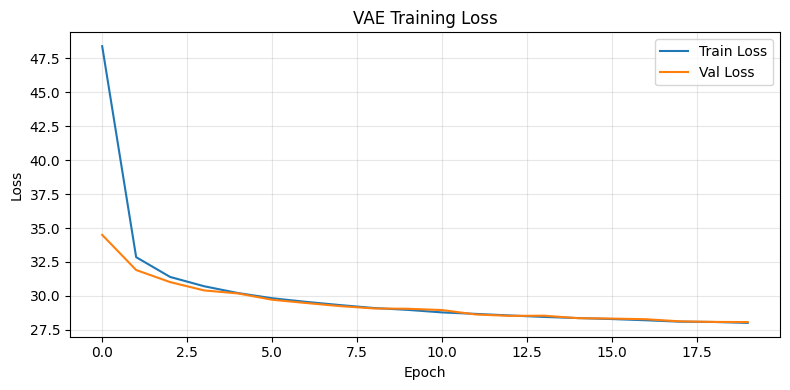

In [9]:
vae, vae_history = train_vae(
    vae, train_digits, val_digits,
    epochs=VAE_EPOCHS, lr=1e-3, device=device,
)

plot_losses(vae_history["train_loss"], vae_history["val_loss"], "VAE Training Loss")

## VAE Quality Check

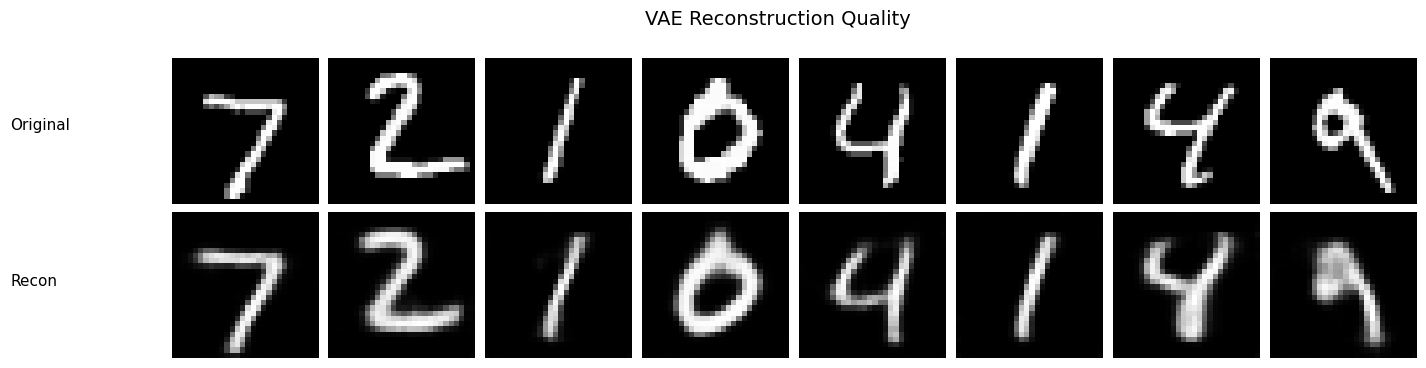

In [10]:
vae.eval()
x_test, _ = next(iter(test_digits))
x_test_01 = (x_test[:8].to(device) + 1) / 2

with torch.no_grad():
    x_recon, _, _ = vae(x_test_01)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))

for i in range(8):
    axes[0, i].imshow(x_test_01[i].detach().cpu().squeeze(0), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(x_recon[i].detach().cpu().squeeze(0), cmap="gray")
    axes[1, i].axis("off")

fig.text(0.02, 0.69, "Original", ha="left", va="center", fontsize=11)
fig.text(0.02, 0.30, "Recon", ha="left", va="center", fontsize=11)

fig.suptitle("VAE Reconstruction Quality", fontsize=14)
plt.subplots_adjust(left=0.12, top=0.86, wspace=0.05, hspace=0.05)
plt.show()


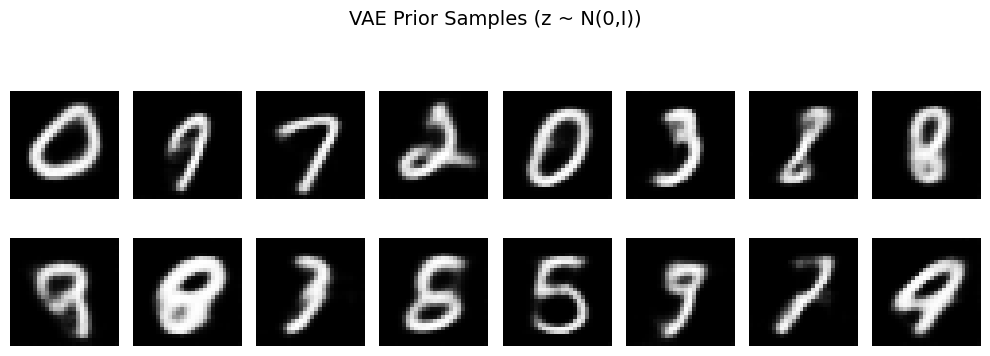

In [11]:
with torch.no_grad():
    z_random = torch.randn(16, VAE_LATENT_DIM, device=device)
    prior_samples = vae.decode(z_random)

show_generated_grid(prior_samples * 2 - 1, nrow=8, title="VAE Prior Samples (z ~ N(0,I))", figsize=(10, 4))

# Pixel-Space Diffusion

Core pixel-space components from the DDPM & DDIM notebook

## Noise Schedule

In [12]:
class NoiseSchedule:
    """Precomputed diffusion constants for a linear beta schedule"""

    def __init__(self, T: int = 1000, beta_start: float = 1e-4, beta_end: float = 0.02, device: str = "cpu"):
        self.T = T
        self.device = device

        betas = torch.linspace(beta_start, beta_end, T, device=device)
        alphas = 1.0 - betas
        alpha_bar = torch.cumprod(alphas, dim=0)
        alpha_bar_prev = F.pad(alpha_bar[:-1], (1, 0), value=1.0)

        self.betas = betas
        self.alphas = alphas
        self.alpha_bar = alpha_bar
        self.alpha_bar_prev = alpha_bar_prev

        self.sqrt_alpha_bar = torch.sqrt(alpha_bar)
        self.sqrt_one_minus_alpha_bar = torch.sqrt(1.0 - alpha_bar)
        self.sqrt_recip_alpha = torch.sqrt(1.0 / alphas)

        self.posterior_variance = betas * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar)

    def _extract(self, arr: torch.Tensor, t: torch.Tensor, x_shape: tuple) -> torch.Tensor:
        batch_size = t.shape[0]
        out = arr.gather(-1, t)
        return out.reshape(batch_size, *((1,) * (len(x_shape) - 1)))

    def q_sample(self, x0: torch.Tensor, t: torch.Tensor, noise: Optional[torch.Tensor] = None):
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_ab = self._extract(self.sqrt_alpha_bar, t, x0.shape)
        sqrt_1_ab = self._extract(self.sqrt_one_minus_alpha_bar, t, x0.shape)
        return sqrt_ab * x0 + sqrt_1_ab * noise, noise

## Pixel-Space U-Net

In [13]:
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        device = t.device
        half = self.dim // 2
        emb = math.log(10000) / (half - 1)
        emb = torch.exp(torch.arange(half, device=device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)


class ResBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, time_dim: int, dropout: float = 0.1):
        super().__init__()
        self.block1 = nn.Sequential(nn.GroupNorm(8, in_ch), nn.SiLU(), nn.Conv2d(in_ch, out_ch, 3, padding=1))
        self.time_proj = nn.Sequential(nn.SiLU(), nn.Linear(time_dim, out_ch))
        self.block2 = nn.Sequential(nn.GroupNorm(8, out_ch), nn.SiLU(), nn.Dropout(dropout), nn.Conv2d(out_ch, out_ch, 3, padding=1))
        self.skip_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.block1(x)
        h = h + self.time_proj(t_emb)[:, :, None, None]
        h = self.block2(h)
        return h + self.skip_conv(x)


class SelfAttention(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.norm = nn.GroupNorm(8, channels)
        self.qkv = nn.Conv2d(channels, channels * 3, 1)
        self.proj = nn.Conv2d(channels, channels, 1)
        self.scale = channels ** -0.5

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)
        qkv = self.qkv(h).reshape(B, 3, C, H * W)
        q, k, v = qkv[:, 0], qkv[:, 1], qkv[:, 2]
        attn = (q.transpose(-1, -2) @ k) * self.scale
        attn = attn.softmax(dim=-1)
        out = (v @ attn.transpose(-1, -2)).reshape(B, C, H, W)
        return x + self.proj(out)


class UNet(nn.Module):
    """Pixel-space U-Net from Notebook 1"""
    def __init__(self, in_ch=1, base_ch=64, time_dim=256, dropout=0.1):
        super().__init__()
        ch1, ch2, ch3 = base_ch, base_ch * 2, base_ch * 4

        self.time_mlp = nn.Sequential(SinusoidalPosEmb(time_dim), nn.Linear(time_dim, time_dim), nn.SiLU(), nn.Linear(time_dim, time_dim))

        self.conv_in = nn.Conv2d(in_ch, ch1, 3, padding=1)
        self.down1_res1 = ResBlock(ch1, ch1, time_dim, dropout)
        self.down1_res2 = ResBlock(ch1, ch1, time_dim, dropout)
        self.down1_pool = nn.Conv2d(ch1, ch1, 3, stride=2, padding=1)

        self.down2_res1 = ResBlock(ch1, ch2, time_dim, dropout)
        self.down2_res2 = ResBlock(ch2, ch2, time_dim, dropout)
        self.down2_pool = nn.Conv2d(ch2, ch2, 3, stride=2, padding=1)

        self.mid_res1 = ResBlock(ch2, ch3, time_dim, dropout)
        self.mid_attn = SelfAttention(ch3)
        self.mid_res2 = ResBlock(ch3, ch3, time_dim, dropout)

        self.up2_upsample = nn.ConvTranspose2d(ch3, ch3, 4, stride=2, padding=1)
        self.up2_res1 = ResBlock(ch3 + ch2, ch2, time_dim, dropout)
        self.up2_res2 = ResBlock(ch2, ch2, time_dim, dropout)

        self.up1_upsample = nn.ConvTranspose2d(ch2, ch2, 4, stride=2, padding=1)
        self.up1_res1 = ResBlock(ch2 + ch1, ch1, time_dim, dropout)
        self.up1_res2 = ResBlock(ch1, ch1, time_dim, dropout)

        self.conv_out = nn.Sequential(nn.GroupNorm(8, ch1), nn.SiLU(), nn.Conv2d(ch1, in_ch, 3, padding=1))

    def forward(self, x, t):
        t_emb = self.time_mlp(t)
        h = self.conv_in(x)
        h1 = self.down1_res2(self.down1_res1(h, t_emb), t_emb)
        h = self.down1_pool(h1)
        h2 = self.down2_res2(self.down2_res1(h, t_emb), t_emb)
        h = self.down2_pool(h2)
        h = self.mid_res2(self.mid_attn(self.mid_res1(h, t_emb)), t_emb)
        h = self.up2_res2(self.up2_res1(torch.cat([self.up2_upsample(h), h2], 1), t_emb), t_emb)
        h = self.up1_res2(self.up1_res1(torch.cat([self.up1_upsample(h), h1], 1), t_emb), t_emb)
        return self.conv_out(h)

## Training & Sampling

In [14]:
def train_diffusion(model, noise_schedule, train_loader, val_loader,
                    config=TrainConfig(), device="cuda"):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr)
    ema = EMA(model, decay=config.ema_decay)
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(config.epochs):
        model.train()
        epoch_loss, n = 0, 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config.epochs}")
        for x0, _ in pbar:
            x0 = x0.to(device)
            t = torch.randint(0, noise_schedule.T, (x0.shape[0],), device=device)
            noise = torch.randn_like(x0)
            xt, _ = noise_schedule.q_sample(x0, t, noise)
            loss = F.mse_loss(model(xt, t), noise)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)
            optimizer.step()
            ema.update(model)
            epoch_loss += loss.item(); n += 1
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        model.eval()
        val_loss, vn = 0, 0
        with torch.no_grad():
            for x0, _ in val_loader:
                x0 = x0.to(device)
                t = torch.randint(0, noise_schedule.T, (x0.shape[0],), device=device)
                noise = torch.randn_like(x0)
                xt, _ = noise_schedule.q_sample(x0, t, noise)
                val_loss += F.mse_loss(model(xt, t), noise).item(); vn += 1

        history["train_loss"].append(epoch_loss / n)
        history["val_loss"].append(val_loss / vn)
        print(f"  => train: {epoch_loss/n:.4f}  val: {val_loss/vn:.4f}")

    ema.apply(model)
    return model, history


@torch.no_grad()
def ddpm_sample(model, ns, n_samples=64, img_shape=(1,28,28), device="cuda"):
    model.eval()
    x = torch.randn(n_samples, *img_shape, device=device)
    for t_val in tqdm(reversed(range(ns.T)), total=ns.T, desc="DDPM"):
        t = torch.full((n_samples,), t_val, device=device, dtype=torch.long)
        eps = model(x, t)
        mean = ns._extract(ns.sqrt_recip_alpha, t, x.shape) * (
            x - ns._extract(ns.betas, t, x.shape) / ns._extract(ns.sqrt_one_minus_alpha_bar, t, x.shape) * eps)
        if t_val > 0:
            x = mean + torch.sqrt(ns._extract(ns.posterior_variance, t, x.shape)) * torch.randn_like(x)
        else:
            x = mean
    return x


@torch.no_grad()
def ddim_sample(model, ns, n_samples=64, img_shape=(1,28,28), device="cuda",
                ddim_steps=50, eta=0.0):
    model.eval()
    step_size = ns.T // ddim_steps
    timesteps = list(reversed(range(0, ns.T, step_size)))
    x = torch.randn(n_samples, *img_shape, device=device)

    for i in tqdm(range(len(timesteps)), desc=f"DDIM({ddim_steps})"):
        t_cur = timesteps[i]
        t_prev = timesteps[i + 1] if i + 1 < len(timesteps) else 0
        t_batch = torch.full((n_samples,), t_cur, device=device, dtype=torch.long)
        ab_t = ns.alpha_bar[t_cur]
        ab_prev = ns.alpha_bar[t_prev] if t_prev > 0 else torch.tensor(1.0, device=device)

        eps = model(x, t_batch)
        x0_pred = ((x - torch.sqrt(1 - ab_t) * eps) / torch.sqrt(ab_t)).clamp(-1, 1)

        sigma = eta * torch.sqrt((1 - ab_prev) / (1 - ab_t) * (1 - ab_t / ab_prev)) if (eta > 0 and t_cur > 0) else torch.tensor(0.0, device=device)
        x = torch.sqrt(ab_prev) * x0_pred + torch.sqrt(1 - ab_prev - sigma**2) * eps
        if sigma > 0:
            x = x + sigma * torch.randn_like(x)
    return x

# Latent Diffusion Model

Instead of running diffusion on 784-dimensional pixel space
(1×28×28), we run it on the 32-dimensional VAE latent space. The diffusion
model only needs to learn the distribution of latent vectors, which is:
- much lower dimensional (32 vs 784 = 24.5× compression)
- smoother (the VAE encoder has already extracted meaningful features)
- faster to train and sample (smaller inputs, simpler model)

Pipeline:
1. Pre-encode the training set: $z = \text{Enc}(x)$ for all images
2. Train a noise predictor $\epsilon_\theta(z_t, t)$ on these latent vectors
3. At inference sample $z_T \sim N(0, I)$, denoise to $z_0$, decode $\hat{x} = \text{Dec}(z_0)$

Since our latent is a flat vector (not spatial), we use an MLP with time
conditioning instead of a U-Net. This is architecturally appropriate for
the 32-dim input and is actually what makes the latent model so much faster.

## Pre-Encode Dataset

In [15]:
@torch.no_grad()
def encode_dataset(vae: ConvVAE, loader: DataLoader, device: str = "cuda") -> Tuple[torch.Tensor, torch.Tensor]:
    """Encode an entire dataset into VAE latent vectors and returns (latents, labels) tensors"""
    vae.eval()
    all_z, all_y = [], []

    for x, y in tqdm(loader, desc="Encoding dataset"):
        # convert [-1, 1] -> [0, 1] for the VAE (which uses sigmoid output)
        x_01 = (x.to(device) + 1) / 2
        mu, _ = vae.encoder(x_01)
        all_z.append(mu.cpu())
        all_y.append(y)

    return torch.cat(all_z, dim=0), torch.cat(all_y, dim=0)


def make_latent_loaders(
    z_train: torch.Tensor,
    z_val: torch.Tensor,
    batch_size: int = 256,
) -> Tuple[DataLoader, DataLoader]:
    """Create DataLoaders from pre-encoded latent vectors"""
    train_ds = TensorDataset(z_train)
    val_ds = TensorDataset(z_val)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader

In [16]:
z_train, y_train = encode_dataset(vae, train_digits, device)
z_val, y_val = encode_dataset(vae, val_digits, device)

print(f"Latent train set: {z_train.shape}")
print(f"Latent val set:   {z_val.shape}")
print(f"Latent mean: {z_train.mean():.3f}, std: {z_train.std():.3f}")

Encoding dataset:   0%|          | 0/422 [00:00<?, ?it/s]

Encoding dataset:   0%|          | 0/47 [00:00<?, ?it/s]

Latent train set: torch.Size([54000, 32])
Latent val set:   torch.Size([6000, 32])
Latent mean: -0.006, std: 0.569


In [17]:
# normalize latents to zero mean, unit variance for diffusion ~ N(0, 1)
z_mean = z_train.mean(dim=0, keepdim=True)
z_std = z_train.std(dim=0, keepdim=True)

z_train_norm = (z_train - z_mean) / (z_std + 1e-6)
z_val_norm = (z_val - z_mean) / (z_std + 1e-6)

print(f"Normalized latent mean: {z_train_norm.mean():.4f}, std: {z_train_norm.std():.4f}")

z_mean_dev = z_mean.to(device)
z_std_dev = z_std.to(device)

latent_train_loader, latent_val_loader = make_latent_loaders(z_train_norm, z_val_norm, batch_size=256)

Normalized latent mean: -0.0000, std: 1.0000


## Latent Noise Predictor (MLP)

The architecture: sinusoidal time embedding → concatenate with noisy latent →
several residual MLP blocks → predict noise.

This is tiny compared to the pixel-space U-Net (~6M params). The latent model
is ~1.5M params, so another factor in the speed advantage.

In [18]:
class MLPResBlock(nn.Module):
    """
    Residual MLP block with time conditioning

    hidden -> LayerNorm -> SiLU -> Linear -> + time_proj -> LayerNorm -> SiLU -> Dropout -> Linear -> + skip
    """
    def __init__(self, dim: int, time_dim: int, dropout: float = 0.1):
        super().__init__()
        self.block1 = nn.Sequential(nn.LayerNorm(dim), nn.SiLU(), nn.Linear(dim, dim))
        self.time_proj = nn.Sequential(nn.SiLU(), nn.Linear(time_dim, dim))
        self.block2 = nn.Sequential(nn.LayerNorm(dim), nn.SiLU(), nn.Dropout(dropout), nn.Linear(dim, dim))

    def forward(self, x: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        h = self.block1(x) + self.time_proj(t_emb)
        return x + self.block2(h)


class LatentNoisePredictor(nn.Module):
    """
    MLP-based noise predictor for flat latent vectors

    Input:  (B, latent_dim) noisy latent + (B,) timestep
    Output: (B, latent_dim) predicted noise
    """
    def __init__(self, latent_dim: int = 32, hidden_dim: int = 256, time_dim: int = 128,
                 n_blocks: int = 8, dropout: float = 0.1):
        super().__init__()
        self.latent_dim = latent_dim

        # time embedding
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        # project latent to hidden dim
        self.input_proj = nn.Linear(latent_dim, hidden_dim)

        # residual blocks
        self.blocks = nn.ModuleList([
            MLPResBlock(hidden_dim, time_dim, dropout) for _ in range(n_blocks)
        ])

        # output projection
        self.output_proj = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, latent_dim),
        )

    def forward(self, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_emb = self.time_mlp(t)
        h = self.input_proj(z)
        for block in self.blocks:
            h = block(h, t_emb)
        return self.output_proj(h)

In [19]:
latent_model = LatentNoisePredictor(
    latent_dim=VAE_LATENT_DIM, hidden_dim=256, time_dim=128, n_blocks=8, dropout=0.1,
).to(device)

n_params_latent = sum(p.numel() for p in latent_model.parameters() if p.requires_grad)
n_params_unet = sum(p.numel() for p in UNet().parameters() if p.requires_grad)

print(f"Latent MLP params:  {n_params_latent:,}")
print(f"Pixel U-Net params: {n_params_unet:,}")
print(f"Ratio: {n_params_unet / n_params_latent:.1f}x smaller latent model")

# sanity check
with torch.no_grad():
    dummy_z = torch.randn(4, VAE_LATENT_DIM, device=device)
    dummy_t = torch.randint(0, 1000, (4,), device=device)
    out = latent_model(dummy_z, dummy_t)
    assert out.shape == dummy_z.shape
    print(f"Forward pass OK: {dummy_z.shape} -> {out.shape}")

Latent MLP params:  1,375,264
Pixel U-Net params: 6,166,081
Ratio: 4.5x smaller latent model
Forward pass OK: torch.Size([4, 32]) -> torch.Size([4, 32])


## Training

Training is identical to pixel-space DDPM, just on latent vectors instead of images.

The NoiseSchedule works on any tensor shape, as it doesn't care whether the input is (B, 1, 28, 28) or (B, 32).

In [20]:
def train_latent_diffusion(
    model: nn.Module,
    noise_schedule: NoiseSchedule,
    train_loader: DataLoader,
    val_loader: DataLoader,
    config: TrainConfig = TrainConfig(),
    device: str = "cuda",
) -> Tuple[nn.Module, dict]:
    """Train a noise predictor on pre-encoded latent vectors."""
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr)
    ema = EMA(model, decay=config.ema_decay)
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(config.epochs):
        model.train()
        epoch_loss, n = 0, 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config.epochs}")
        for (z0,) in pbar:
            z0 = z0.to(device)
            B = z0.shape[0]

            t = torch.randint(0, noise_schedule.T, (B,), device=device)
            noise = torch.randn_like(z0)
            zt, _ = noise_schedule.q_sample(z0, t, noise)

            noise_pred = model(zt, t)
            loss = F.mse_loss(noise_pred, noise)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)
            optimizer.step()
            ema.update(model)

            epoch_loss += loss.item()
            n += 1
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        model.eval()
        val_loss, vn = 0, 0
        with torch.no_grad():
            for (z0,) in val_loader:
                z0 = z0.to(device)
                t = torch.randint(0, noise_schedule.T, (z0.shape[0],), device=device)
                noise = torch.randn_like(z0)
                zt, _ = noise_schedule.q_sample(z0, t, noise)
                val_loss += F.mse_loss(model(zt, t), noise).item()
                vn += 1

        history["train_loss"].append(epoch_loss / n)
        history["val_loss"].append(val_loss / vn)
        print(f"  => train: {epoch_loss/n:.4f}  val: {val_loss/vn:.4f}")

    ema.apply(model)
    return model, history

## DDPM & DDIM Sampling

In [21]:
@torch.no_grad()
def latent_ddpm_sample(model, ns, vae, n_samples=64, latent_dim=32,
                       z_mean=None, z_std=None, device="cuda"):
    """
    DDPM sampling in latent space + VAE decoding

    Returns decoded images in [-1, 1] range
    """
    model.eval()
    z = torch.randn(n_samples, latent_dim, device=device)

    for t_val in tqdm(reversed(range(ns.T)), total=ns.T, desc="Latent DDPM"):
        t = torch.full((n_samples,), t_val, device=device, dtype=torch.long)
        eps = model(z, t)
        mean = ns._extract(ns.sqrt_recip_alpha, t, z.shape) * (
            z - ns._extract(ns.betas, t, z.shape) / ns._extract(ns.sqrt_one_minus_alpha_bar, t, z.shape) * eps)
        if t_val > 0:
            z = mean + torch.sqrt(ns._extract(ns.posterior_variance, t, z.shape)) * torch.randn_like(z)
        else:
            z = mean

    # denormalize latents back to VAE's scale
    if z_mean is not None and z_std is not None:
        z = z * (z_std + 1e-6) + z_mean

    # decode with VAE
    vae.eval()
    images = vae.decode(z) # [0, 1]
    images = images * 2 - 1 # -> [-1, 1]
    return images


@torch.no_grad()
def latent_ddim_sample(model, ns, vae, n_samples=64, latent_dim=32,
                       z_mean=None, z_std=None, device="cuda",
                       ddim_steps=50, eta=0.0):
    """DDIM sampling in latent space + VAE decoding"""
    model.eval()
    step_size = ns.T // ddim_steps
    timesteps = list(reversed(range(0, ns.T, step_size)))
    z = torch.randn(n_samples, latent_dim, device=device)

    for i in tqdm(range(len(timesteps)), desc=f"Latent DDIM({ddim_steps})"):
        t_cur = timesteps[i]
        t_prev = timesteps[i + 1] if i + 1 < len(timesteps) else 0
        t_batch = torch.full((n_samples,), t_cur, device=device, dtype=torch.long)
        ab_t = ns.alpha_bar[t_cur]
        ab_prev = ns.alpha_bar[t_prev] if t_prev > 0 else torch.tensor(1.0, device=device)

        eps = model(z, t_batch)
        z0_pred = ((z - torch.sqrt(1 - ab_t) * eps) / torch.sqrt(ab_t))

        sigma = eta * torch.sqrt((1 - ab_prev) / (1 - ab_t) * (1 - ab_t / ab_prev)) if (eta > 0 and t_cur > 0) else torch.tensor(0.0, device=device)
        z = torch.sqrt(ab_prev) * z0_pred + torch.sqrt(1 - ab_prev - sigma**2) * eps
        if sigma > 0:
            z = z + sigma * torch.randn_like(z)

    # denormalize + decode
    if z_mean is not None and z_std is not None:
        z = z * (z_std + 1e-6) + z_mean

    vae.eval()
    images = vae.decode(z) * 2 - 1
    return images

# Experiments

## Train Pixel-Space Diffusion Model

In [22]:
T = 1000
PIXEL_EPOCHS = 30

pixel_ns = NoiseSchedule(T=T, device=device)
pixel_model = UNet(in_ch=1, base_ch=64, time_dim=256, dropout=0.1).to(device)

print(f"Pixel-space U-Net: {sum(p.numel() for p in pixel_model.parameters()):,} params")

Pixel-space U-Net: 6,166,081 params


Epoch 1/30:   0%|          | 0/422 [00:00<?, ?it/s]

  => train: 0.0630  val: 0.0318


Epoch 2/30:   0%|          | 0/422 [00:00<?, ?it/s]

  => train: 0.0324  val: 0.0276


Epoch 3/30:   0%|          | 0/422 [00:00<?, ?it/s]

...

  => train: 0.0220  val: 0.0221


Epoch 29/30:   0%|          | 0/422 [00:00<?, ?it/s]

  => train: 0.0222  val: 0.0213


Epoch 30/30:   0%|          | 0/422 [00:00<?, ?it/s]

  => train: 0.0221  val: 0.0212


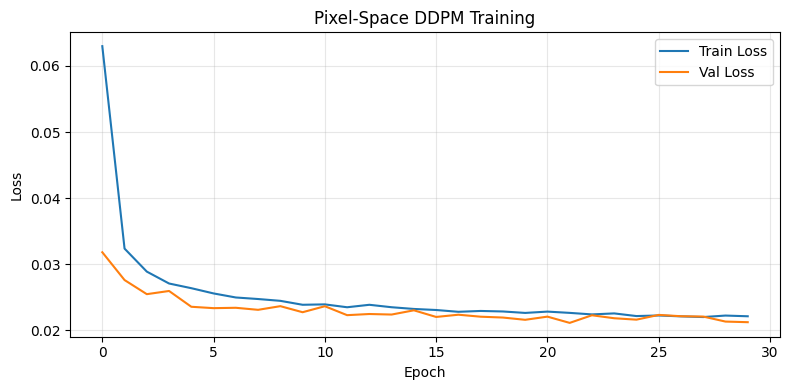

In [23]:
pixel_model, pixel_history = train_diffusion(
    pixel_model, pixel_ns, train_digits, val_digits,
    config=TrainConfig(epochs=PIXEL_EPOCHS, lr=2e-4), device=device,
)
plot_losses(pixel_history["train_loss"], pixel_history["val_loss"], "Pixel-Space DDPM Training")

## Train Latent-Space Diffusion Model

In [24]:
LATENT_EPOCHS = 30

latent_ns = NoiseSchedule(T=T, device=device)
latent_model = LatentNoisePredictor(
    latent_dim=VAE_LATENT_DIM, hidden_dim=256, time_dim=128, n_blocks=8,
).to(device)

print(f"Latent MLP: {sum(p.numel() for p in latent_model.parameters()):,} params")

Latent MLP: 1,375,264 params


Epoch 1/30:   0%|          | 0/211 [00:00<?, ?it/s]

  => train: 0.4340  val: 0.2958


Epoch 2/30:   0%|          | 0/211 [00:00<?, ?it/s]

  => train: 0.2976  val: 0.2757


Epoch 3/30:   0%|          | 0/211 [00:00<?, ?it/s]

...

  => train: 0.2191  val: 0.2132


Epoch 29/30:   0%|          | 0/211 [00:00<?, ?it/s]

  => train: 0.2173  val: 0.2154


Epoch 30/30:   0%|          | 0/211 [00:00<?, ?it/s]

  => train: 0.2165  val: 0.2116


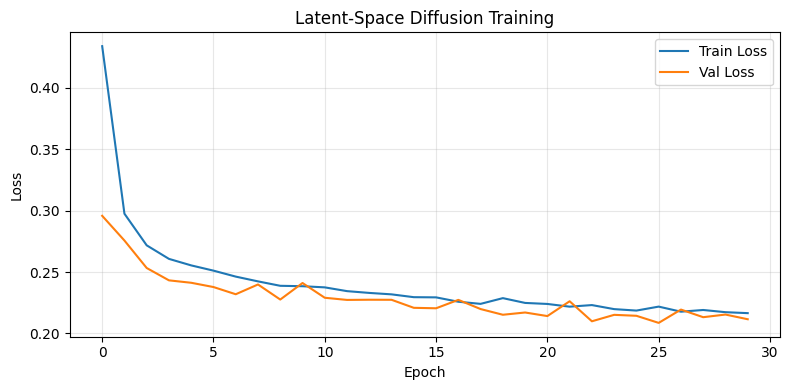

In [25]:
latent_model, latent_history = train_latent_diffusion(
    latent_model, latent_ns, latent_train_loader, latent_val_loader,
    config=TrainConfig(epochs=LATENT_EPOCHS, lr=2e-4), device=device,
)
plot_losses(latent_history["train_loss"], latent_history["val_loss"], "Latent-Space Diffusion Training")

## Generate & Compare

### DDPM Sampling

In [26]:
# pixel-space DDPM
start = time.time()
pixel_ddpm_samples = ddpm_sample(pixel_model, pixel_ns, n_samples=64, device=device)
pixel_ddpm_time = time.time() - start
print(f"Pixel DDPM (1000 steps): {pixel_ddpm_time:.2f}s")

# latent-space DDPM
start = time.time()
latent_ddpm_samples = latent_ddpm_sample(
    latent_model, latent_ns, vae, n_samples=64,
    latent_dim=VAE_LATENT_DIM, z_mean=z_mean_dev, z_std=z_std_dev, device=device,
)
latent_ddpm_time = time.time() - start
print(f"Latent DDPM (1000 steps): {latent_ddpm_time:.2f}s")

print(f"\nSpeedup: {pixel_ddpm_time / latent_ddpm_time:.1f}x")

DDPM:   0%|          | 0/1000 [00:00<?, ?it/s]

Pixel DDPM (1000 steps): 6.75s


Latent DDPM:   0%|          | 0/1000 [00:00<?, ?it/s]

Latent DDPM (1000 steps): 2.64s

Speedup: 2.6x


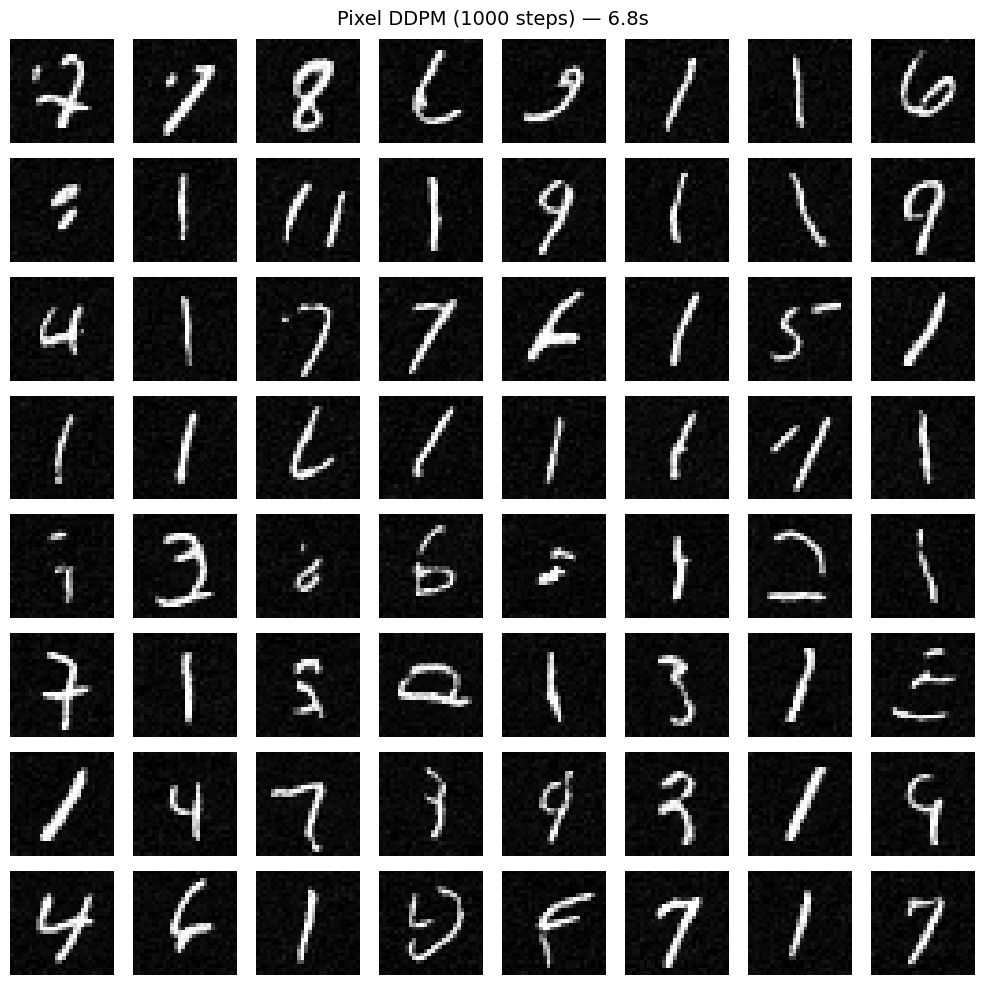

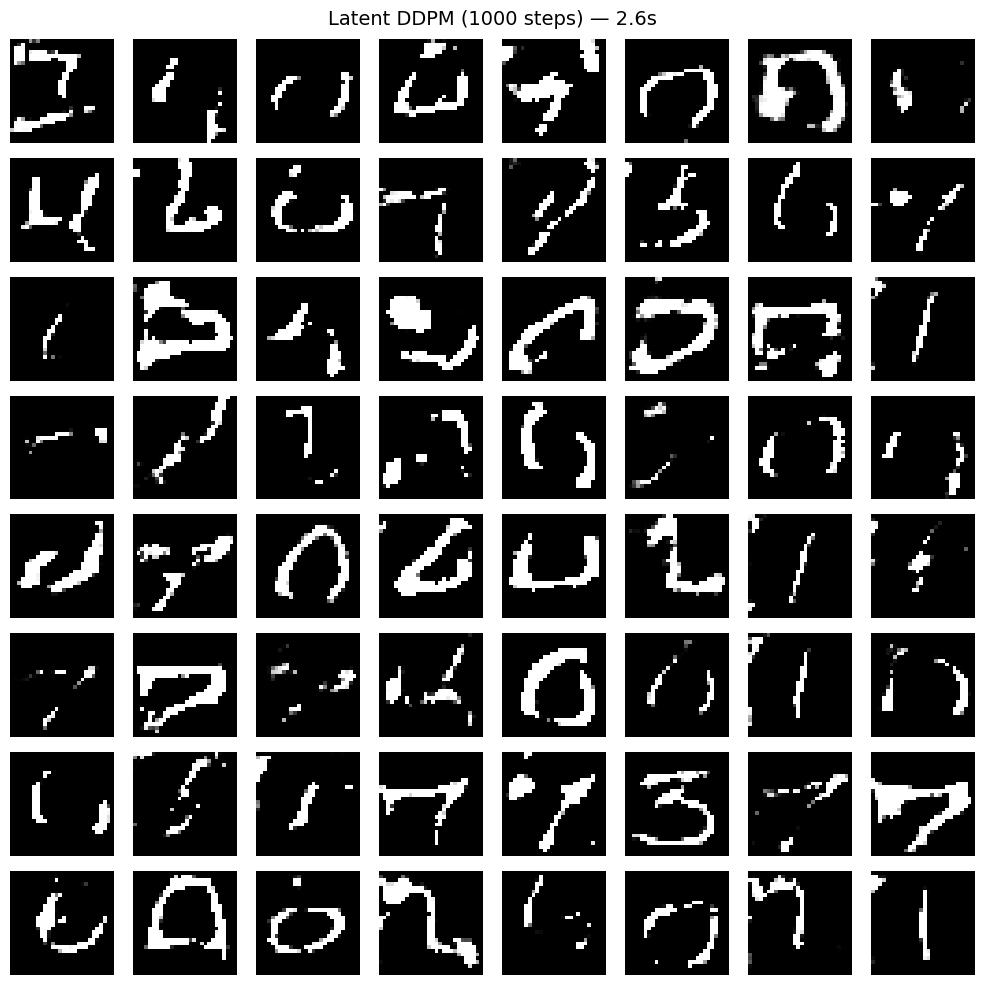

In [27]:
show_generated_grid(pixel_ddpm_samples, nrow=8, title=f"Pixel DDPM (1000 steps) — {pixel_ddpm_time:.1f}s", figsize=(10, 10))
show_generated_grid(latent_ddpm_samples, nrow=8, title=f"Latent DDPM (1000 steps) — {latent_ddpm_time:.1f}s", figsize=(10, 10))

### DDIM Sampling

In [28]:
ddim_configs = [
    {"ddim_steps": 10, "eta": 1.0},
    {"ddim_steps": 25, "eta": 1.0},
    {"ddim_steps": 50, "eta": 1.0},
]

results = {}

for cfg in ddim_configs:
    steps = cfg["ddim_steps"]
    eta = cfg["eta"]
    label = f"DDIM-{steps} (η={eta})"

    # pixel-space DDIM
    start = time.time()
    px = ddim_sample(pixel_model, pixel_ns, n_samples=64, device=device, **cfg)
    px_time = time.time() - start

    # latent-space DDIM
    start = time.time()
    lt = latent_ddim_sample(
        latent_model, latent_ns, vae, n_samples=64,
        latent_dim=VAE_LATENT_DIM, z_mean=z_mean_dev, z_std=z_std_dev,
        device=device, **cfg,
    )
    lt_time = time.time() - start

    results[label] = {
        "pixel_samples": px, "pixel_time": px_time,
        "latent_samples": lt, "latent_time": lt_time,
    }
    print(f"{label}: pixel={px_time:.3f}s  latent={lt_time:.3f}s  speedup={px_time/lt_time:.1f}x")

DDIM(10):   0%|          | 0/10 [00:00<?, ?it/s]

Latent DDIM(10):   0%|          | 0/10 [00:00<?, ?it/s]

DDIM-10 (η=1.0): pixel=0.105s  latent=0.040s  speedup=2.6x


DDIM(25):   0%|          | 0/25 [00:00<?, ?it/s]

Latent DDIM(25):   0%|          | 0/25 [00:00<?, ?it/s]

DDIM-25 (η=1.0): pixel=0.183s  latent=0.089s  speedup=2.1x


DDIM(50):   0%|          | 0/50 [00:00<?, ?it/s]

Latent DDIM(50):   0%|          | 0/50 [00:00<?, ?it/s]

DDIM-50 (η=1.0): pixel=0.350s  latent=0.159s  speedup=2.2x


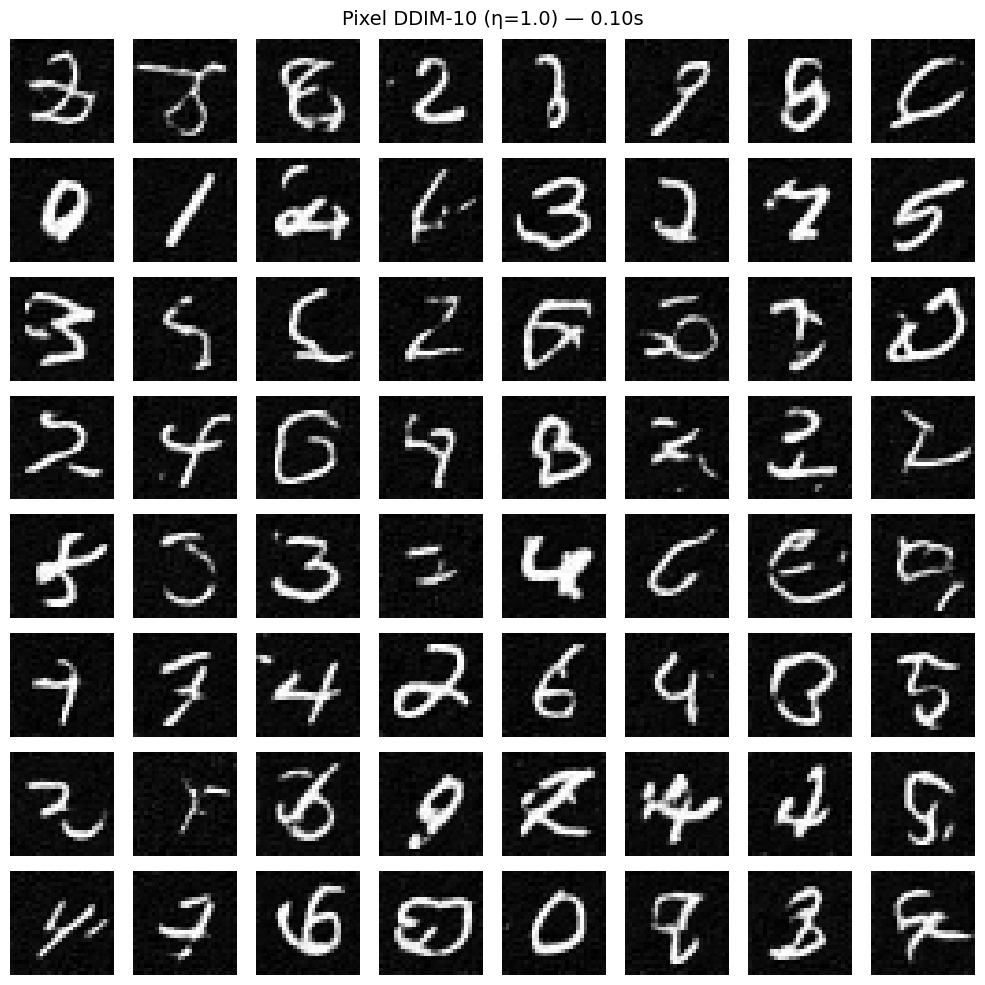

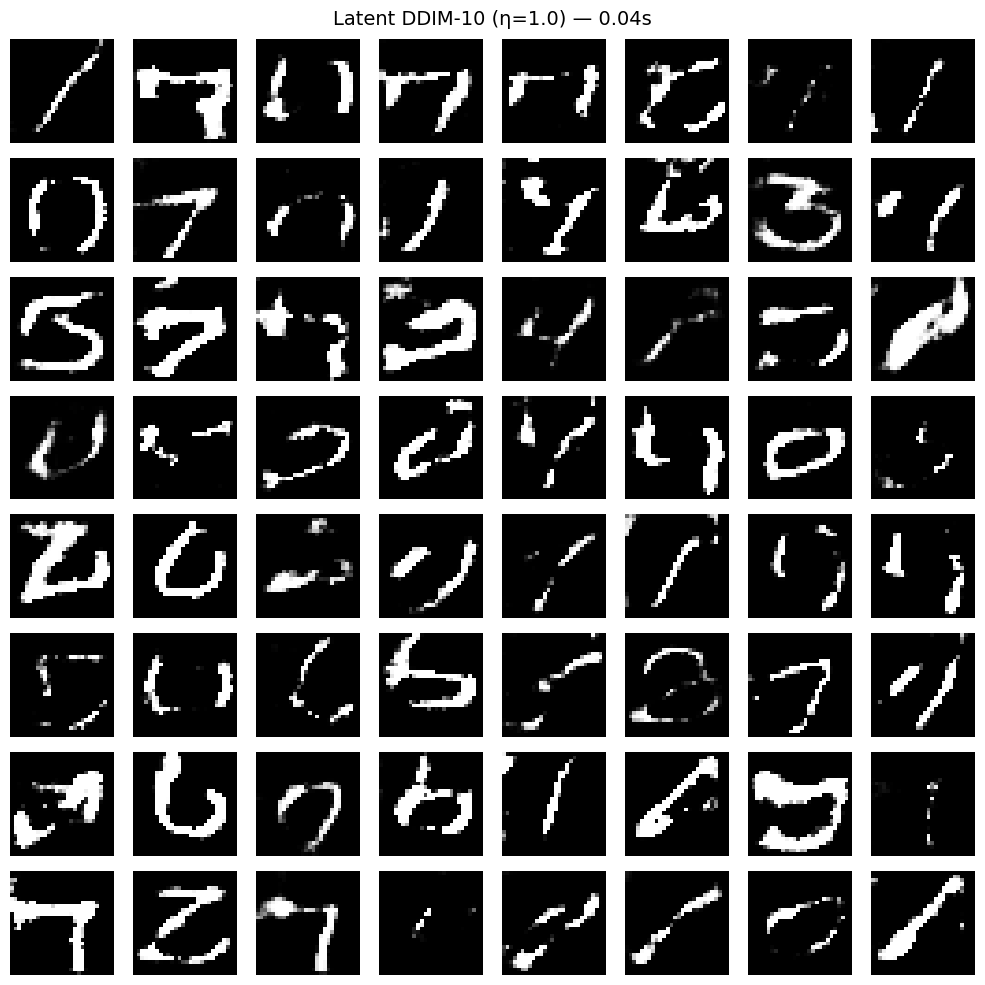

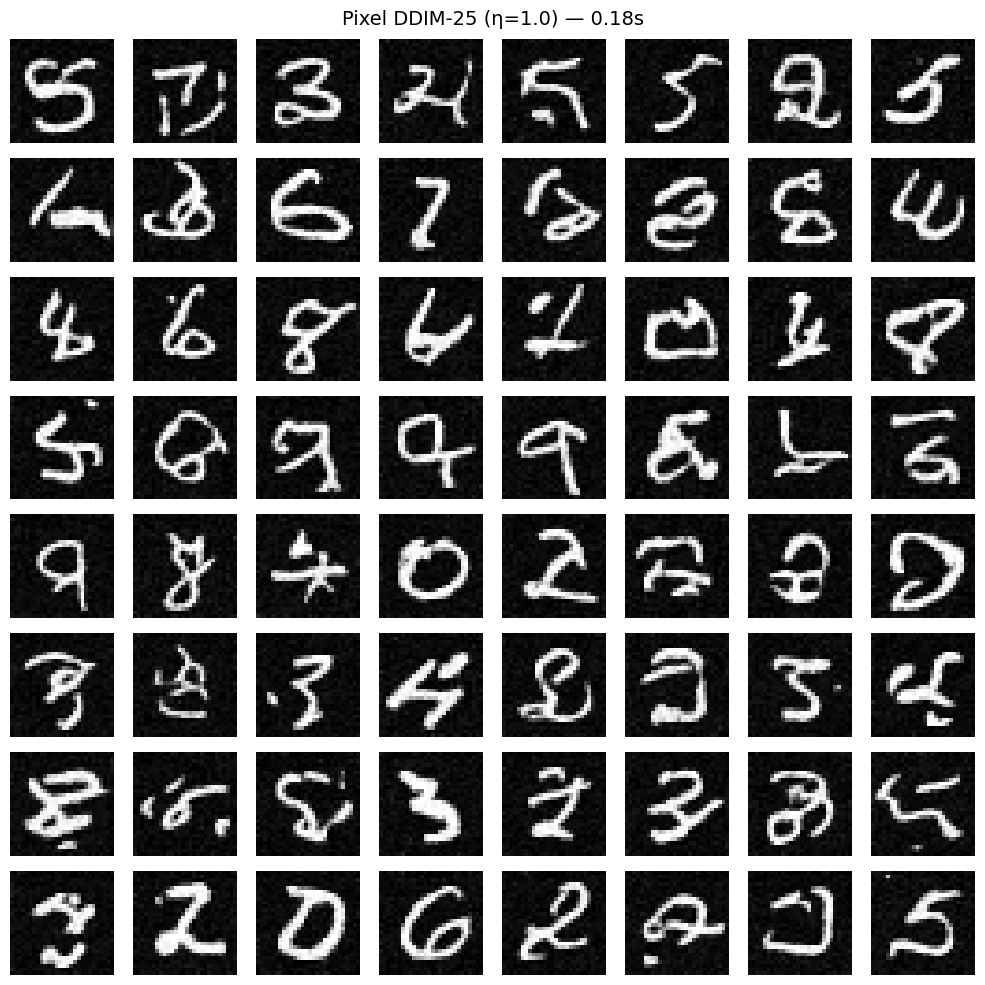

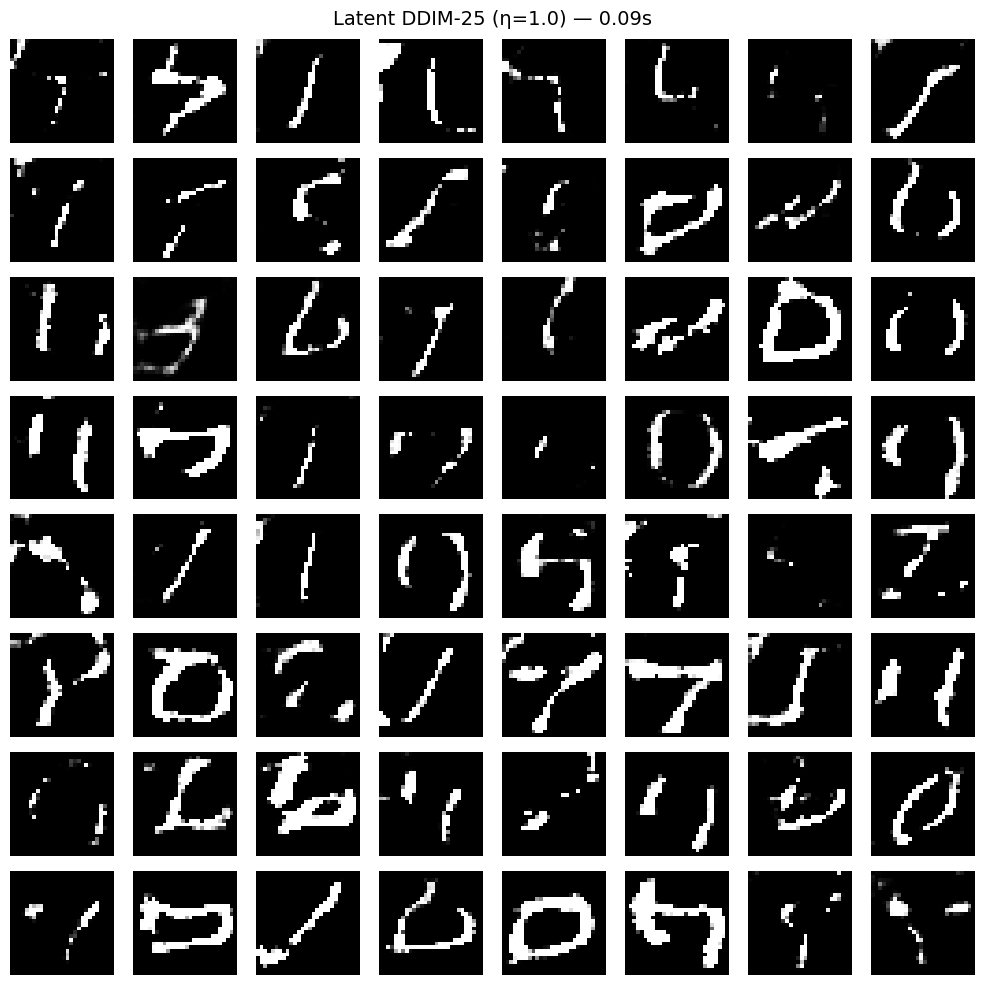

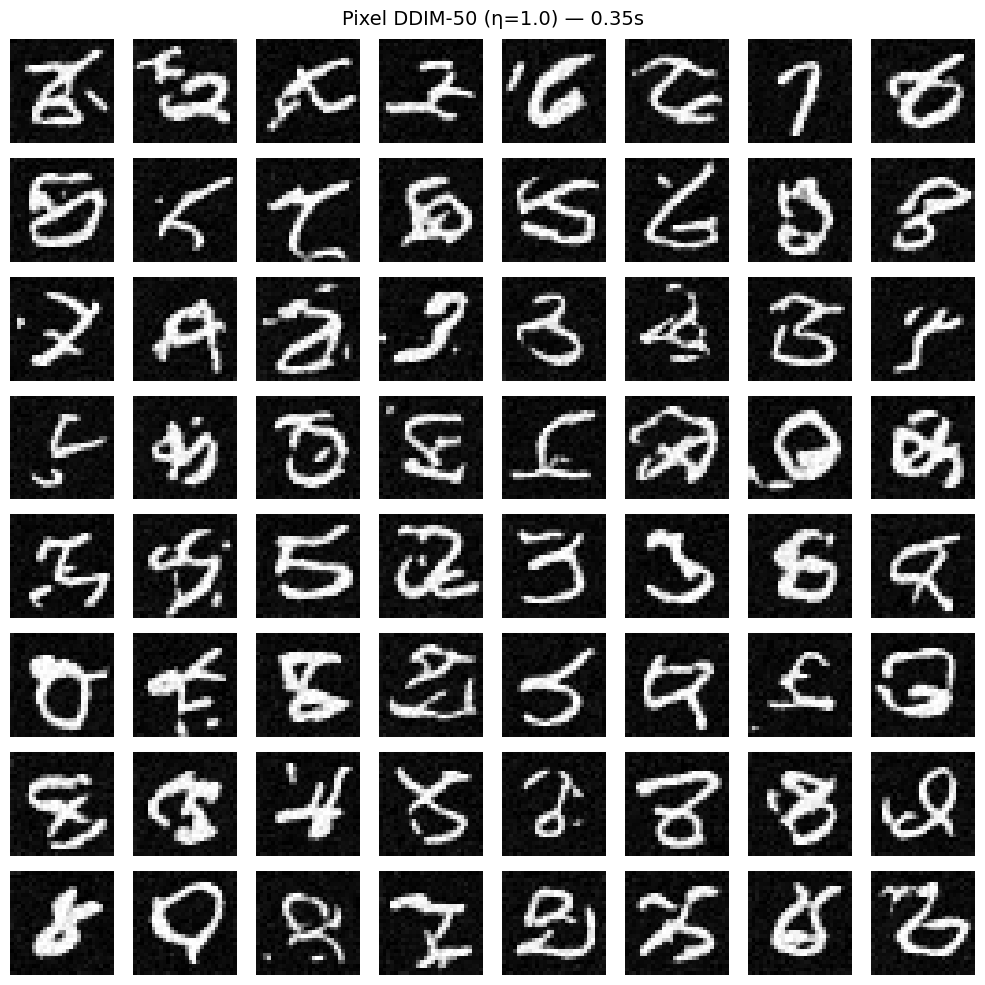

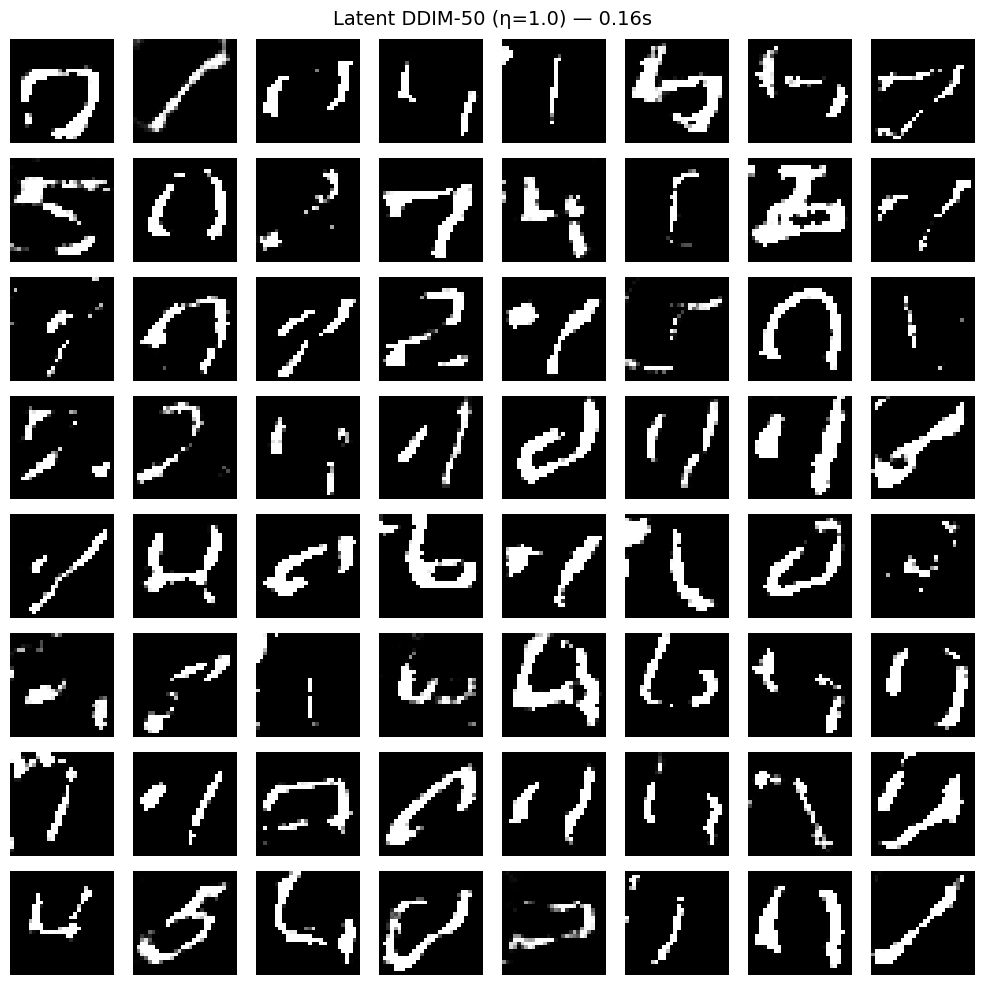

In [29]:
for label, res in results.items():
    show_generated_grid(res["pixel_samples"], nrow=8,
                        title=f"Pixel {label} — {res['pixel_time']:.2f}s", figsize=(10, 10))
    show_generated_grid(res["latent_samples"], nrow=8,
                        title=f"Latent {label} — {res['latent_time']:.2f}s", figsize=(10, 10))

### Latent DDIM with η=0

In DDPM & DDIM we observed that pixel-space DDIM with η=0 collapses at higher
step counts due to deterministic error accumulation through the U-Net.
Let's check if the latent model has the same problem.

Latent DDIM(10):   0%|          | 0/10 [00:00<?, ?it/s]

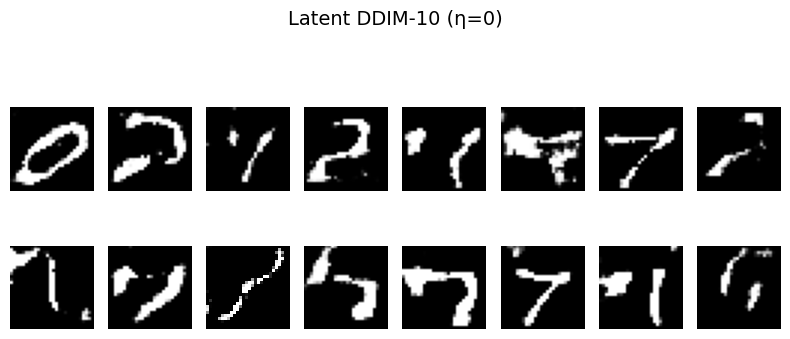

Latent DDIM(25):   0%|          | 0/25 [00:00<?, ?it/s]

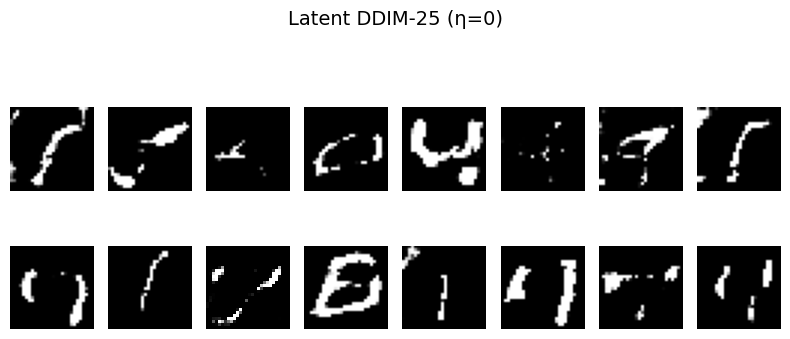

Latent DDIM(50):   0%|          | 0/50 [00:00<?, ?it/s]

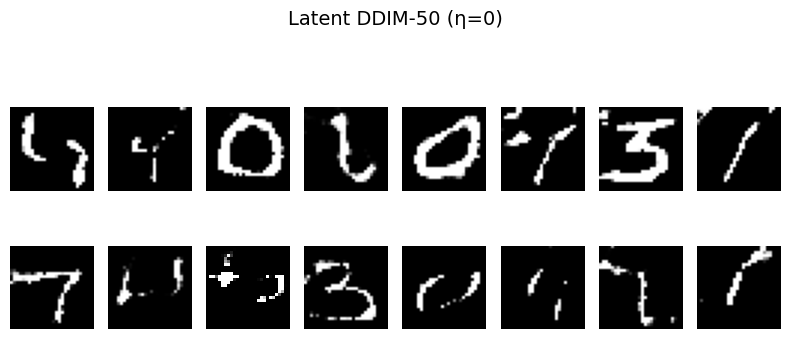

Latent DDIM(100):   0%|          | 0/100 [00:00<?, ?it/s]

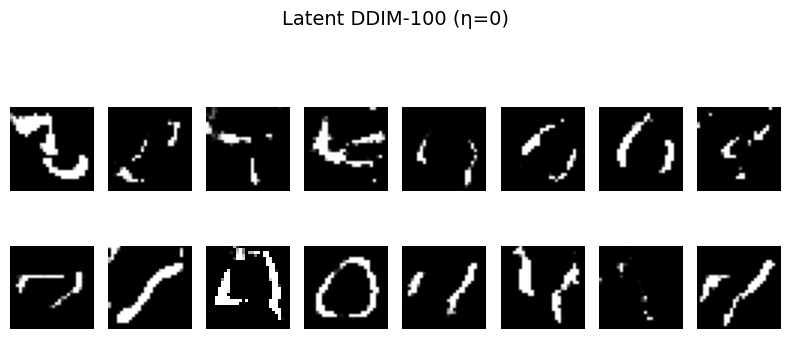

In [30]:
ddim_eta0_steps = [10, 25, 50, 100]

for steps in ddim_eta0_steps:
    samples = latent_ddim_sample(
        latent_model, latent_ns, vae, n_samples=16,
        latent_dim=VAE_LATENT_DIM, z_mean=z_mean_dev, z_std=z_std_dev,
        device=device, ddim_steps=steps, eta=0.0,
    )
    show_generated_grid(samples, nrow=8,
                        title=f"Latent DDIM-{steps} (η=0)", figsize=(8, 4))

# Comparison & Results

## Timing Chart

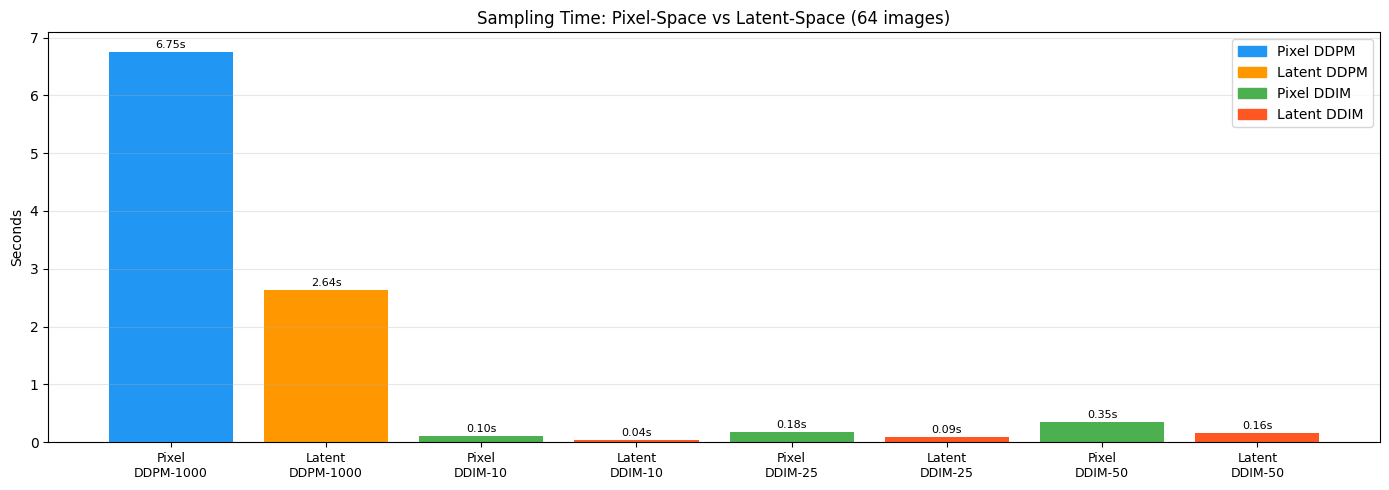

In [31]:
methods, times, colors, categories = [], [], [], []

# DDPM
methods += ["Pixel\nDDPM-1000", "Latent\nDDPM-1000"]
times += [pixel_ddpm_time, latent_ddpm_time]
colors += ["#2196F3", "#FF9800"]

# DDIM variants
for label, res in results.items():
    short = label.replace("DDIM-", "").replace(" (η=1.0)", "")
    methods += [f"Pixel\nDDIM-{short}", f"Latent\nDDIM-{short}"]
    times += [res["pixel_time"], res["latent_time"]]
    colors += ["#4CAF50", "#FF5722"]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(range(len(methods)), times, color=colors)
ax.set_xticks(range(len(methods)))
ax.set_xticklabels(methods, fontsize=9)
ax.set_ylabel("Seconds")
ax.set_title("Sampling Time: Pixel-Space vs Latent-Space (64 images)")

for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(times)*0.01,
            f"{t:.2f}s", ha="center", fontsize=8)

ax.legend(handles=[
    Patch(color="#2196F3", label="Pixel DDPM"),
    Patch(color="#FF9800", label="Latent DDPM"),
    Patch(color="#4CAF50", label="Pixel DDIM"),
    Patch(color="#FF5722", label="Latent DDIM"),
], loc="upper right")

ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Speedup Table

In [32]:
print("=" * 70)
print(f"{'Method':<30} {'Pixel (s)':<12} {'Latent (s)':<12} {'Speedup':<10}")
print("=" * 70)
print(f"{'DDPM-1000':<30} {pixel_ddpm_time:<12.3f} {latent_ddpm_time:<12.3f} {pixel_ddpm_time/latent_ddpm_time:.1f}x")
for label, res in results.items():
    print(f"{label:<30} {res['pixel_time']:<12.3f} {res['latent_time']:<12.3f} "
          f"{res['pixel_time']/res['latent_time']:.1f}x")
print("=" * 70)

Method                         Pixel (s)    Latent (s)   Speedup   
DDPM-1000                      6.752        2.635        2.6x
DDIM-10 (η=1.0)                0.105        0.040        2.6x
DDIM-25 (η=1.0)                0.183        0.089        2.1x
DDIM-50 (η=1.0)                0.350        0.159        2.2x


## Quality Comparison

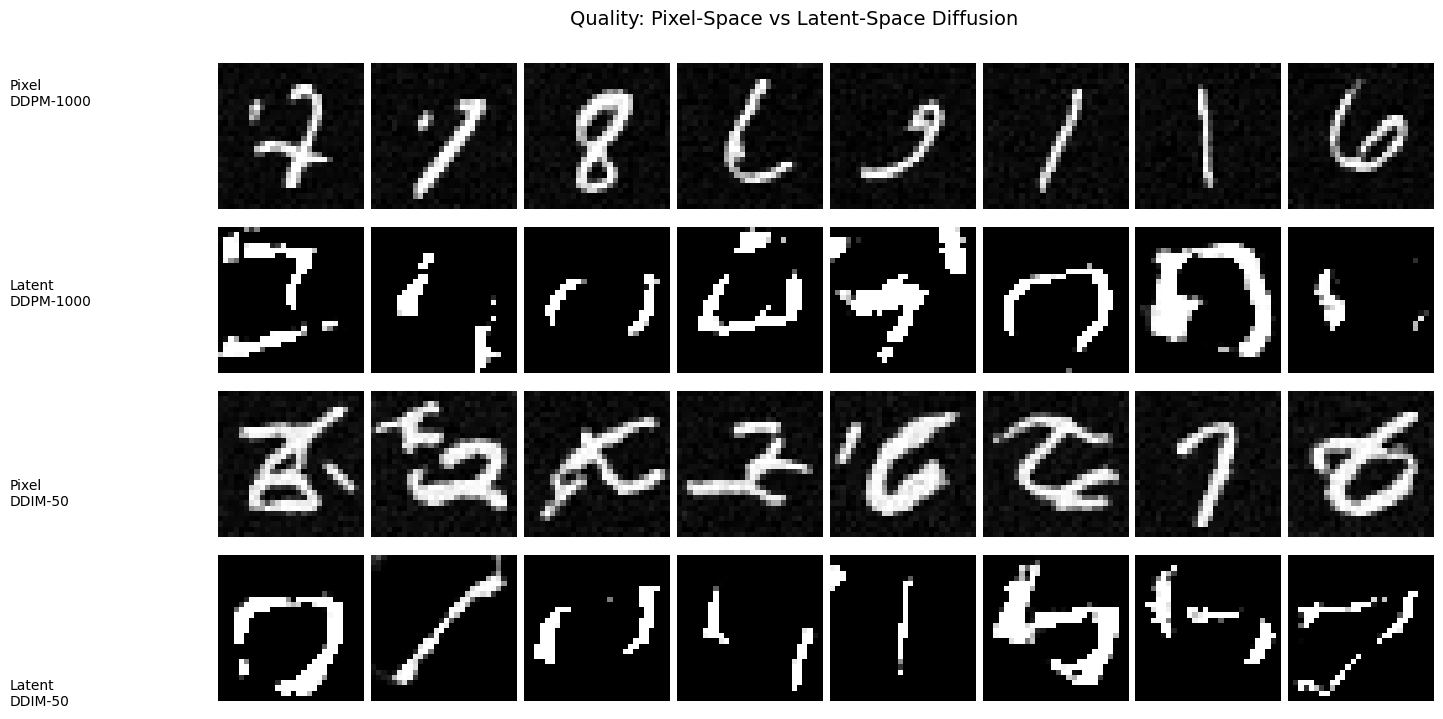

In [35]:
fig, axes = plt.subplots(4, 8, figsize=(16, 8))

row_data = [
    ("Pixel\nDDPM-1000", pixel_ddpm_samples),
    ("Latent\nDDPM-1000", latent_ddpm_samples),
    ("Pixel\nDDIM-50", results["DDIM-50 (η=1.0)"]["pixel_samples"]),
    ("Latent\nDDIM-50", results["DDIM-50 (η=1.0)"]["latent_samples"]),
]

for row_idx, (label, samples) in enumerate(row_data):
    vis = denormalize(samples[:8]).cpu()
    for j in range(8):
        axes[row_idx, j].imshow(vis[j].squeeze(0), cmap="gray")
        axes[row_idx, j].axis("off")

ys = [1 - (i + 0.5) / len(row_data) for i in range(len(row_data))]
for y, (label, _) in zip(ys, row_data):
    fig.text(0.01, y, label, ha="left", va="center", fontsize=10)

fig.suptitle("Quality: Pixel-Space vs Latent-Space Diffusion", fontsize=14)
plt.subplots_adjust(left=0.14, top=0.92, wspace=0.05, hspace=0.05)
plt.show()

## Model Size & Training Time Comparison

In [34]:
pixel_params = sum(p.numel() for p in pixel_model.parameters())
latent_params = sum(p.numel() for p in latent_model.parameters())
vae_params = sum(p.numel() for p in vae.parameters())

print("=== Model Sizes ===")
print(f"Pixel U-Net: {pixel_params:>10,} params")
print(f"Latent MLP: {latent_params:>10,} params")
print(f"VAE (encoder+dec): {vae_params:>10,} params")
print(f"LDM total (VAE+MLP): {latent_params+vae_params:>10,} params")
print()
print(f"Input dimensionality: pixel=784 (28×28), latent={VAE_LATENT_DIM} ({784/VAE_LATENT_DIM:.0f}x compression)")

=== Model Sizes ===
Pixel U-Net:  6,166,081 params
Latent MLP:  1,375,264 params
VAE (encoder+dec):    416,193 params
LDM total (VAE+MLP):  1,791,457 params

Input dimensionality: pixel=784 (28×28), latent=32 (24x compression)


# Results Discussion

## Pixel-space vs Latent-space Diffusion

### Sample quality

* **Pixel DDPM-1000** is the cleanest baseline in this run. Digits are coherent, with continuous strokes and fewer artifacts.
* **Pixel DDIM-50** stays reasonably close in quality to DDPM while being much faster, which is what we expect from DDIM step skipping.
* **Latent DDPM-1000** looks noticeably worse: strokes are fragmented, often “blocky”, and some digits lose internal structure.
* **Latent DDIM-50** shows similar issues to latent DDPM: the sampler is faster, but decoding still produces broken shapes.

Overall, latent-space generation is currently limited by the latent representation + VAE decoder, not by the diffusion sampler itself. Even if diffusion denoises latents well, the final image quality cannot exceed what the VAE can reliably decode from those latents.

### Why latent samples look worse here

In my implementation, latent diffusion is run on a flat 32-dimensional latent vector. That choice is simple and fast, but it discards spatial structure. Unlike pixel-space diffusion (U-Net on 2D images), the latent denoiser is an MLP operating on a vector, so it has no built-in “locality” prior. As a result:

* small latent errors can turn into large visual artifacts after decoding,
* the decoder may be sensitive to latents that are slightly off the training manifold,
* the model tends to produce discontinuous or incomplete strokes.

So, the main bottleneck is that flat latent space → limited capacity to preserve geometry → decoder amplifies imperfections.


## Timing & Speedup

### What the timing plot shows

* **DDPM-1000:** latent sampling is clearly faster than pixel sampling (about 2.6× in this run).
  Even with 1000 steps, the latent model’s per-step compute is smaller, although the speedup is not "24×" because we still pay for VAE decoding and general overhead.
* **DDIM:** both pipelines become very fast, but latent remains consistently faster:

  * DDIM-10: ~0.10s (pixel) vs ~0.04s (latent)
  * DDIM-25: ~0.18s (pixel) vs ~0.09s (latent)
  * DDIM-50: ~0.35s (pixel) vs ~0.16s (latent)

So the pattern is stable: latent diffusion reduces per-step cost, while DDIM reduces the number of steps.

# Conclusions

* **Pixel-space diffusion produces better MNIST digits than latent-space diffusion.** The latent samples show broken strokes and blocky artifacts, which suggests the current latent pipeline is **VAE-limited** (and additionally affected by using a flat 32-dimensional latent).
* **Latent-space diffusion is consistently faster**, with the clearest win at DDPM-1000 (~2.6×) and about ~2× speedup for DDIM variants at 10/25/50 steps.
* **Best practical choice from these results:**

  * If I care about visual quality, I should prefer pixel DDPM (best) or pixel DDIM-50 (good quality + much faster).
  * If I care about speed, latent DDIM is the fastest, but the current quality cost is significant.
* **What I would change to make latent diffusion competitive:**

  1. switch from a flat latent vector to spatial latents ($C \times 7 \times 7$) and use a small U-Net denoiser in latent space
  2. increase latent capacity (more channels / higher latent dimensionality)
  3. improve VAE reconstruction quality and decoder robustness (because it sets the quality ceiling)
  4. reduce mismatch between "encoded latents" and "generated latents" (so the decoder sees latents closer to what it was trained on)